# Stock Price Forecasting with ONNX

This notebook demonstrates end-to-end stock price forecasting using LSTM and ONNX deployment.

---

## Cell 1: Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from onnx_forecasting_utils import (
    load_stock_data, parse_and_sort_dates, handle_missing_values,
    detect_and_handle_outliers, split_data_chronological, normalize_data,
    calculate_moving_averages, calculate_bollinger_bands, calculate_atr,
    calculate_rsi, calculate_macd, calculate_volume_indicators,
    apply_all_features, create_rolling_windows,
    LSTMConfig, build_lstm_model, compile_model, create_and_train_lstm,
    convert_to_onnx, verify_onnx, ONNXInferenceSession,
    compare_frameworks_inference,
    evaluate_forecasts, plot_predictions_vs_actual, plot_residuals,
    create_forecast_report, compare_models
)

sns.set_style('whitegrid')
print("All libraries imported successfully!")

2025-12-09 13:08:59.918287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765303739.959889  197808 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765303739.969826  197808 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-09 13:09:00.022578: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All libraries imported successfully!


---

## Cell 2: Load and Explore Stock Data

In [ ]:
data_path = 'data/Stocks/goog.us.txt'
df = load_stock_data(data_path, date_column='Date')

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nDataset info:")
print(df.info())

print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (916, 7)
Date range: 2014-03-27 00:00:00 to 2017-11-10 00:00:00

First few rows:
        Date    Open    High     Low   Close  Volume  OpenInt
0 2014-03-27  568.00  568.00  552.92  558.46   13052        0
1 2014-03-28  561.20  566.43  558.67  559.99   41003        0
2 2014-03-31  566.89  567.00  556.93  556.97   10772        0
3 2014-04-01  558.71  568.45  558.71  567.16    7932        0
4 2014-04-02  599.99  604.83  562.19  567.00  146697        0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     916 non-null    datetime64[ns]
 1   Open     916 non-null    float64       
 2   High     916 non-null    float64       
 3   Low      916 non-null    float64       
 4   Close    916 non-null    float64       
 5   Volume   916 non-null    int64         
 6   OpenInt  916 non-null    int64         
dtypes: 

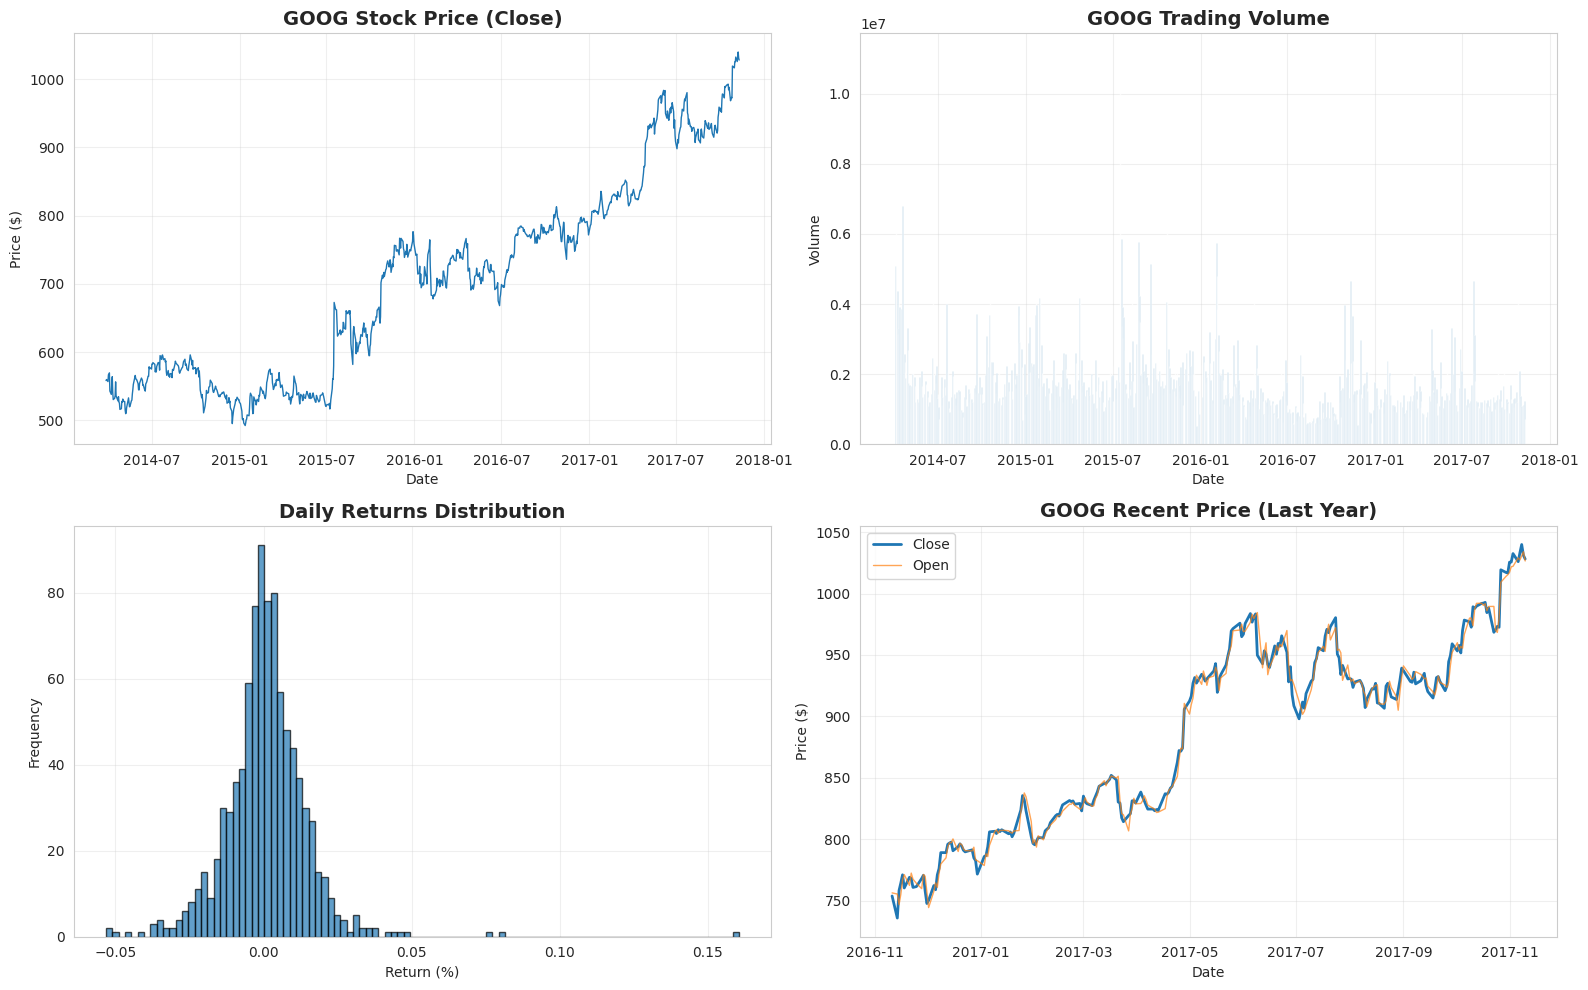


Basic Statistics:
              Open         High          Low        Close        Volume
count   916.000000   916.000000   916.000000   916.000000  9.160000e+02
mean    702.895757   708.114831   697.058311   702.812259  1.725988e+06
std     144.142510   144.697658   143.888208   144.496999  9.540722e+05
min     494.650000   495.980000   487.560000   492.550000  7.932000e+03
25%     560.525000   565.097500   555.627500   559.792500  1.173610e+06
50%     710.780000   718.380000   703.450000   711.005000  1.511322e+06
75%     793.825000   798.057500   787.887750   794.257500  1.988164e+06
max    1033.990000  1048.390000  1028.450000  1039.850000  1.116490e+07


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(df['Date'], df['Close'], linewidth=1)
axes[0, 0].set_title('GOOG Stock Price (Close)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].bar(df['Date'], df['Volume'], width=1, alpha=0.7)
axes[0, 1].set_title('GOOG Trading Volume', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Volume')
axes[0, 1].grid(True, alpha=0.3)

price_changes = df['Close'].pct_change()
axes[1, 0].hist(price_changes.dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Daily Returns Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Return (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

recent_df = df.tail(252)
axes[1, 1].plot(recent_df['Date'], recent_df['Close'], label='Close', linewidth=2)
axes[1, 1].plot(recent_df['Date'], recent_df['Open'], label='Open', linewidth=1, alpha=0.7)
axes[1, 1].set_title('GOOG Recent Price (Last Year)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Price ($)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBasic Statistics:")
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

---

## Cell 4: Data Preprocessing

In [ ]:
df = parse_and_sort_dates(df, date_column='Date')
df = handle_missing_values(df, method='forward_fill')

price_cols = ['Open', 'High', 'Low', 'Close']
df = detect_and_handle_outliers(df, columns=price_cols, method='iqr', threshold=1.5)

print("Data preprocessing complete")
print(f"Cleaned dataset shape: {df.shape}")
print(f"Missing values after preprocessing: {df.isnull().sum().sum()}")

Data preprocessing complete
Cleaned dataset shape: (916, 7)
Missing values after preprocessing: 0


---

## Cell 5: Feature Engineering - Technical Indicators

In [ ]:
print("Calculating technical indicators...")

df = calculate_moving_averages(df, price_column='Close', windows=[5, 10, 20, 50])
df = calculate_bollinger_bands(df, price_column='Close', window=20, num_std=2.0)
df = calculate_atr(df, high_col='High', low_col='Low', close_col='Close', window=14)
df = calculate_rsi(df, price_column='Close', window=14)
df = calculate_macd(df, price_column='Close', fast_period=12, slow_period=26, signal_period=9)
df = calculate_volume_indicators(df, volume_column='Volume', price_column='Close')

# Calculate percentage change (target variable)
# Model will output 0.1 for 10% change, -0.05 for -5% change, etc.
df['Price_Change_Pct'] = df['Close'].pct_change()

df = df.dropna()

print(f"Technical indicators calculated")
print(f"Dataset shape after feature engineering: {df.shape}")
print(f"\nAvailable features:")
print(df.columns.tolist())
print(f"\nTarget variable statistics (Price_Change_Pct):")
print(f"  Mean: {df['Price_Change_Pct'].mean():.6f} ({df['Price_Change_Pct'].mean()*100:.4f}%)")
print(f"  Std:  {df['Price_Change_Pct'].std():.6f} ({df['Price_Change_Pct'].std()*100:.4f}%)")
print(f"  Min:  {df['Price_Change_Pct'].min():.6f} ({df['Price_Change_Pct'].min()*100:.4f}%)")
print(f"  Max:  {df['Price_Change_Pct'].max():.6f} ({df['Price_Change_Pct'].max()*100:.4f}%)")

Calculating technical indicators...
Technical indicators calculated
Dataset shape after feature engineering: (867, 28)

Available features:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt', 'SMA_5', 'EMA_5', 'SMA_10', 'EMA_10', 'SMA_20', 'EMA_20', 'SMA_50', 'EMA_50', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'ATR', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'Volume_SMA_20', 'Volume_Ratio', 'OBV', 'Price_Change_Pct']

Target variable statistics (Price_Change_Pct):
  Mean: 0.000809 (0.0809%)
  Std:  0.013909 (1.3909%)
  Min:  -0.053179 (-5.3179%)
  Max:  0.160524 (16.0524%)


---

## Cell 6: Visualize Technical Indicators

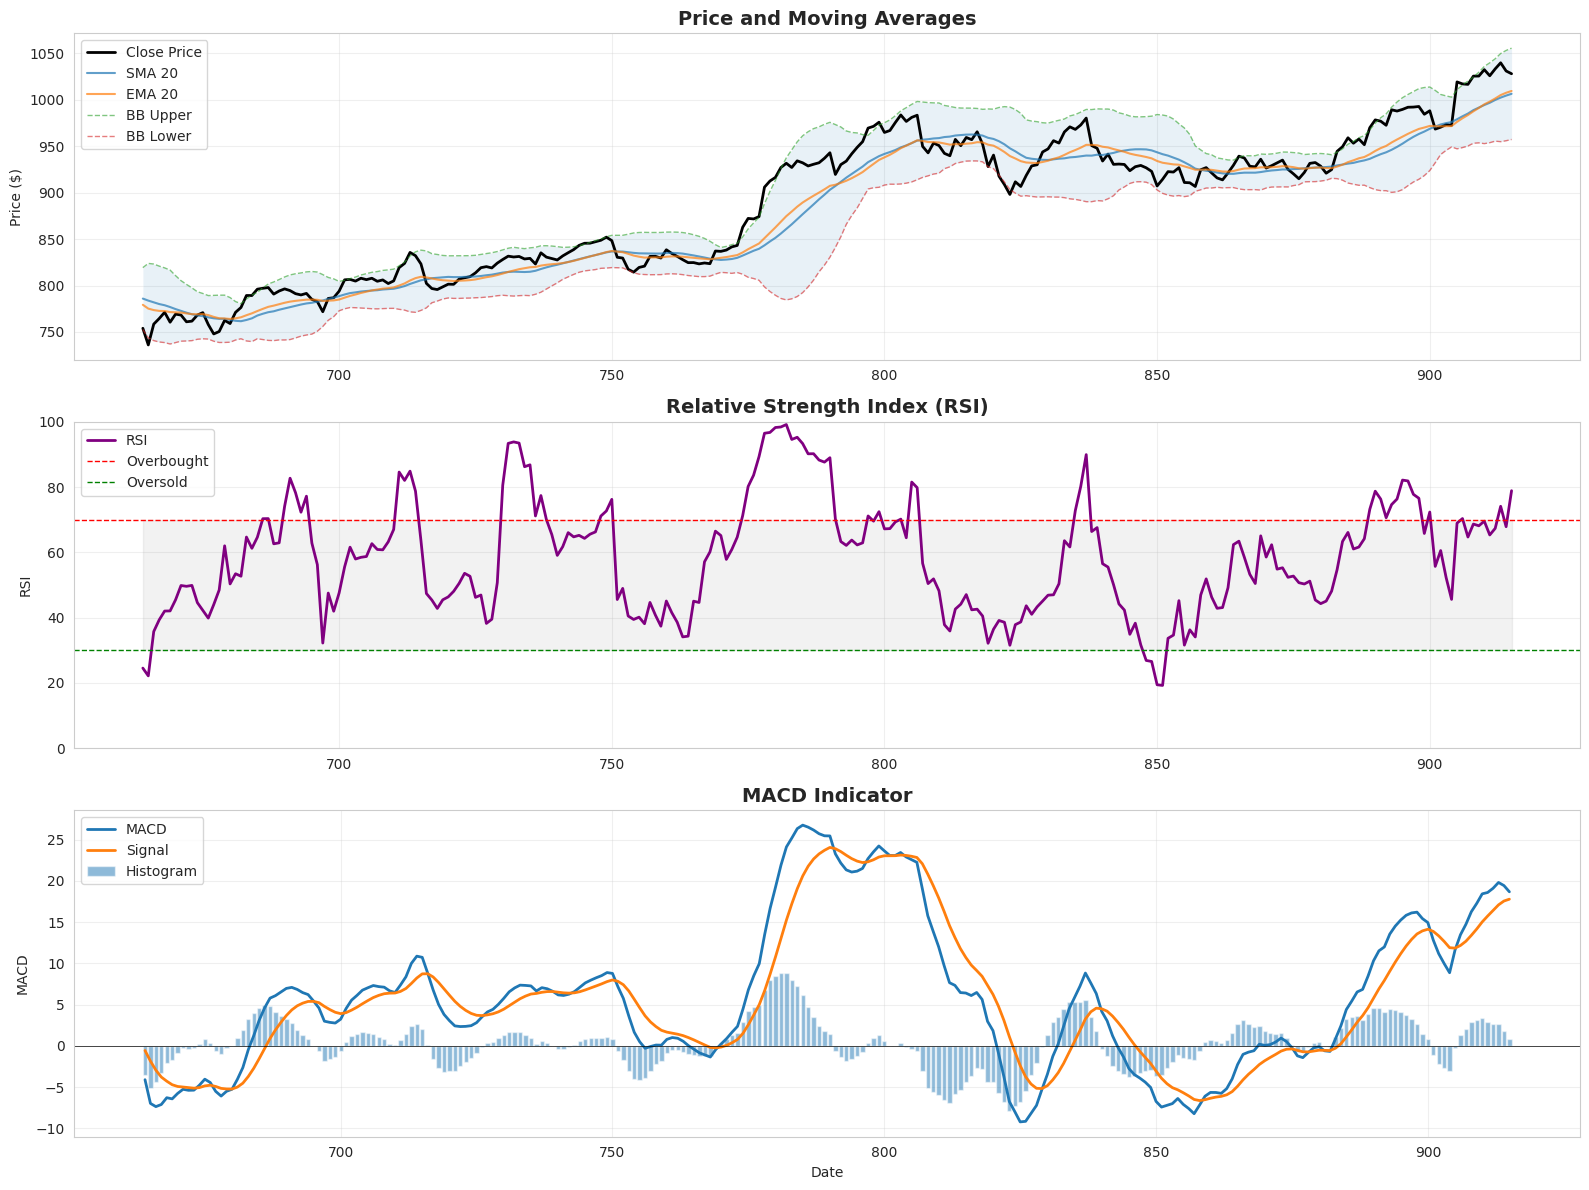

Technical indicators visualization complete


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

recent_df = df.tail(252)
ax1 = axes[0]
ax1.plot(recent_df.index, recent_df['Close'], label='Close Price', linewidth=2, color='black')
ax1.plot(recent_df.index, recent_df['SMA_20'], label='SMA 20', linewidth=1.5, alpha=0.7)
ax1.plot(recent_df.index, recent_df['EMA_20'], label='EMA 20', linewidth=1.5, alpha=0.7)
ax1.plot(recent_df.index, recent_df['BB_Upper'], label='BB Upper', linewidth=1, linestyle='--', alpha=0.6)
ax1.plot(recent_df.index, recent_df['BB_Lower'], label='BB Lower', linewidth=1, linestyle='--', alpha=0.6)
ax1.fill_between(recent_df.index, recent_df['BB_Upper'], recent_df['BB_Lower'], alpha=0.1)
ax1.set_title('Price and Moving Averages', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(recent_df.index, recent_df['RSI'], label='RSI', linewidth=2, color='purple')
ax2.axhline(y=70, color='r', linestyle='--', linewidth=1, label='Overbought')
ax2.axhline(y=30, color='g', linestyle='--', linewidth=1, label='Oversold')
ax2.fill_between(recent_df.index, 30, 70, alpha=0.1, color='gray')
ax2.set_title('Relative Strength Index (RSI)', fontsize=14, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.plot(recent_df.index, recent_df['MACD'], label='MACD', linewidth=2)
ax3.plot(recent_df.index, recent_df['MACD_Signal'], label='Signal', linewidth=2)
ax3.bar(recent_df.index, recent_df['MACD_Histogram'], label='Histogram', alpha=0.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_title('MACD Indicator', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('MACD')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Technical indicators visualization complete")

---

## Cell 7: Select Features for Training

In [ ]:
feature_cols = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'SMA_20', 'EMA_20', 'RSI', 'MACD', 'MACD_Signal',
    'BB_Width', 'ATR', 'Volume_Ratio'
]

target_col = 'Price_Change_Pct'

print(f"Selected features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTarget variable: {target_col}")
print(f"Note: Model predicts percentage change (e.g., 0.1 = 10% increase)")

Selected features (13):
   1. Close
   2. Open
   3. High
   4. Low
   5. Volume
   6. SMA_20
   7. EMA_20
   8. RSI
   9. MACD
  10. MACD_Signal
  11. BB_Width
  12. ATR
  13. Volume_Ratio

Target variable: Price_Change_Pct
Note: Model predicts percentage change (e.g., 0.1 = 10% increase)


---

## Cell 8: Split Data Chronologically

Data Split Summary
Training set:     606 samples (49 to 654)
Validation set:   130 samples (655 to 784)
Test set:         131 samples (785 to 915)


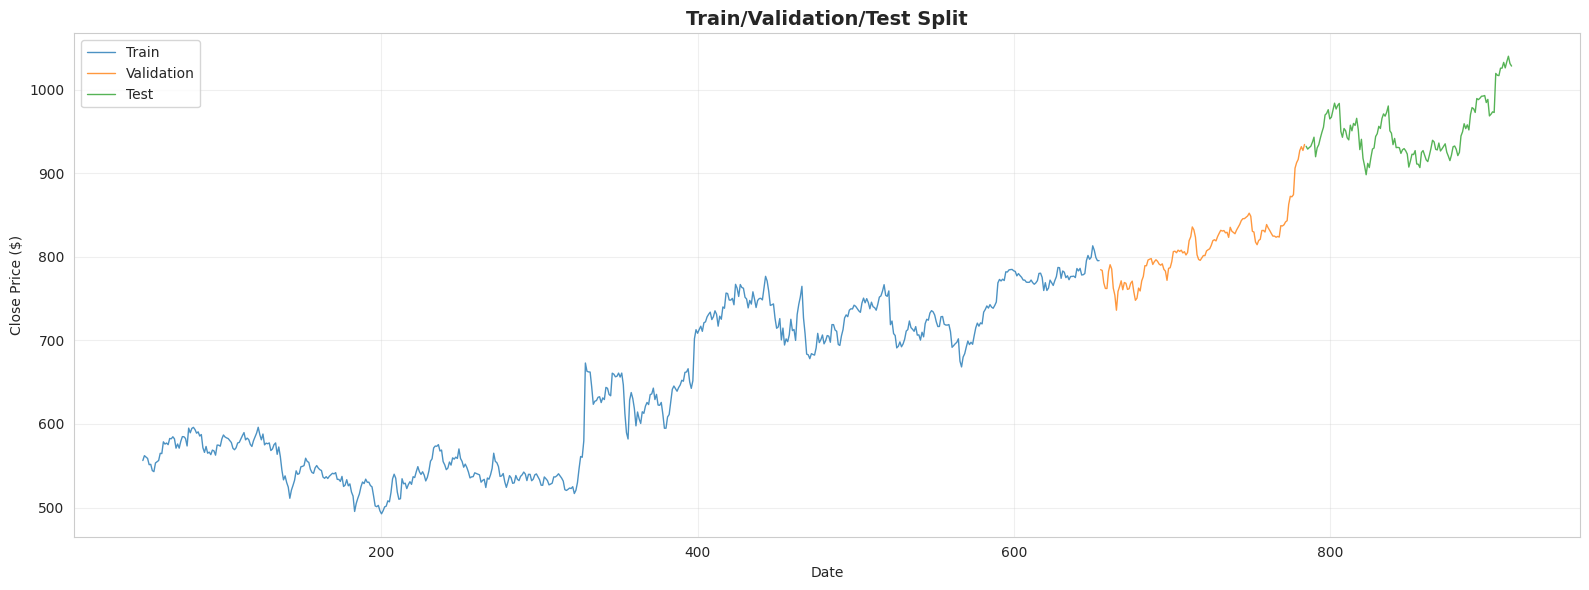

In [ ]:
train_df, val_df, test_df = split_data_chronological(df, train_ratio=0.7, val_ratio=0.15)

print("=" * 60)
print("Data Split Summary")
print("=" * 60)
print(f"Training set:   {len(train_df):5d} samples ({train_df.index.min()} to {train_df.index.max()})")
print(f"Validation set: {len(val_df):5d} samples ({val_df.index.min()} to {val_df.index.max()})")
print(f"Test set:       {len(test_df):5d} samples ({test_df.index.min()} to {test_df.index.max()})")
print("=" * 60)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train_df.index, train_df['Close'], label='Train', linewidth=1, alpha=0.8)
ax.plot(val_df.index, val_df['Close'], label='Validation', linewidth=1, alpha=0.8)
ax.plot(test_df.index, test_df['Close'], label='Test', linewidth=1, alpha=0.8)
ax.set_title('Train/Validation/Test Split', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Cell 9: Normalize Features

In [ ]:
# Include target column in normalization
all_cols = feature_cols + [target_col]

train_scaled, scaler = normalize_data(train_df, columns=all_cols, scaler_type='minmax')

val_scaled = val_df.copy()
val_scaled[all_cols] = scaler.transform(val_df[all_cols])

test_scaled = test_df.copy()
test_scaled[all_cols] = scaler.transform(test_df[all_cols])

print("Feature normalization complete")
print(f"\nScaler range: {scaler.feature_range}")
print(f"\nSample scaled values (first 5 rows, first 5 features):")
print(train_scaled[feature_cols].head())
print(f"\nTarget variable range in training set:")
print(f"  Original: [{train_df[target_col].min():.6f}, {train_df[target_col].max():.6f}]")
print(f"  Scaled:   [{train_scaled[target_col].min():.6f}, {train_scaled[target_col].max():.6f}]")

Feature normalization complete

Scaler range: (0, 1)

Sample scaled values (first 5 rows, first 5 features):
       Close      Open      High       Low    Volume    SMA_20    EMA_20  \
49  0.198964  0.196907  0.193577  0.193243  0.113277  0.109431  0.125425   
50  0.217026  0.193584  0.208669  0.215631  0.093869  0.117273  0.131076   
51  0.212129  0.204515  0.210851  0.221487  0.077289  0.122809  0.135656   
52  0.206794  0.196721  0.199252  0.212419  0.053577  0.127463  0.139220   
53  0.183429  0.195572  0.193358  0.191763  0.087328  0.131928  0.139907   

         RSI      MACD  MACD_Signal  BB_Width       ATR  Volume_Ratio  
49  0.752134  0.442501     0.442497  0.205070  0.191834      0.173639  
50  0.740452  0.454618     0.451902  0.197190  0.173512      0.151551  
51  0.716287  0.459960     0.460786  0.197219  0.158998      0.130396  
52  0.640114  0.459699     0.467827  0.196146  0.145685      0.097586  
53  0.507342  0.445367     0.469810  0.181967  0.151587      0.147278  

T

---

## Cell 10: Create Sequences for LSTM

In [ ]:
sequence_length = 60

# Create sequences with features only (X) and target separately (y)
X_train, _ = create_rolling_windows(
    train_scaled[feature_cols].values,
    window_size=sequence_length,
    step_size=1
)

X_val, _ = create_rolling_windows(
    val_scaled[feature_cols].values,
    window_size=sequence_length,
    step_size=1
)

X_test, _ = create_rolling_windows(
    test_scaled[feature_cols].values,
    window_size=sequence_length,
    step_size=1
)

# Extract target (percentage change) separately
# Target is the percentage change at the next time step
y_train = train_scaled[target_col].values[sequence_length:]
y_val = val_scaled[target_col].values[sequence_length:]
y_test = test_scaled[target_col].values[sequence_length:]

# Reshape to (n_samples, 1) for single output
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("=" * 60)
print("Sequence Creation Summary")
print("=" * 60)
print(f"Sequence length: {sequence_length} days")
print(f"Number of features: {len(feature_cols)}")
print(f"Target: {target_col} (percentage change)")
print(f"\nTraining sequences:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation sequences: X={X_val.shape}, y={y_val.shape}")
print(f"Test sequences:       X={X_test.shape}, y={y_test.shape}")
print("=" * 60)

Sequence Creation Summary
Sequence length: 60 days
Number of features: 13
Target: Price_Change_Pct (percentage change)

Training sequences:   X=(546, 60, 13), y=(546, 1)
Validation sequences: X=(70, 60, 13), y=(70, 1)
Test sequences:       X=(71, 60, 13), y=(71, 1)


---

## Cell 11: Build and Train LSTM Model

Building and training LSTM model...
Loss function: MAE (Mean Absolute Error)
Optimizer: Adam
Building LSTM model with config: LSTMConfig(sequence_length=60, n_features=13, lstm_units_1=512, lstm_units_2=256, dropout_rate=0.2, dense_units=128, output_dim=1, learning_rate=0.001, batch_size=32, epochs=50, validation_split=0.0)


I0000 00:00:1765303747.806438  197808 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6



Model Architecture:


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 512)        │     1,077,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼─────────────────────

I0000 00:00:1765303755.464104  197932 cuda_dnn.cc:529] Loaded cuDNN version 90300


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1737 - mae: 0.1737 - mape: 129938.6093
Epoch 1: val_loss improved from None to 0.10606, saving model to models/lstm_model_best.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.1237 - mae: 0.1237 - mape: 555216.8750 - val_loss: 0.1061 - val_mae: 0.1061 - val_mape: 44.8286 - learning_rate: 0.0010
Epoch 2/50
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0734 - mae: 0.0734 - mape: 137406.9265
Epoch 2: val_loss improved from 0.10606 to 0.05500, saving model to models/lstm_model_best.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0704 - mae: 0.0704 - mape: 356994.7188 - val_loss: 0.0550 - val_mae: 0.0550 - val_mape: 20.9255 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0696 - mae: 0.0696 - mape: 180633.4487
Epoch 3: val_loss improved from 0.05500 to 0.04072, saving model to models/lstm_model_best.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0679 - mae: 0.0679 - mape: 482431

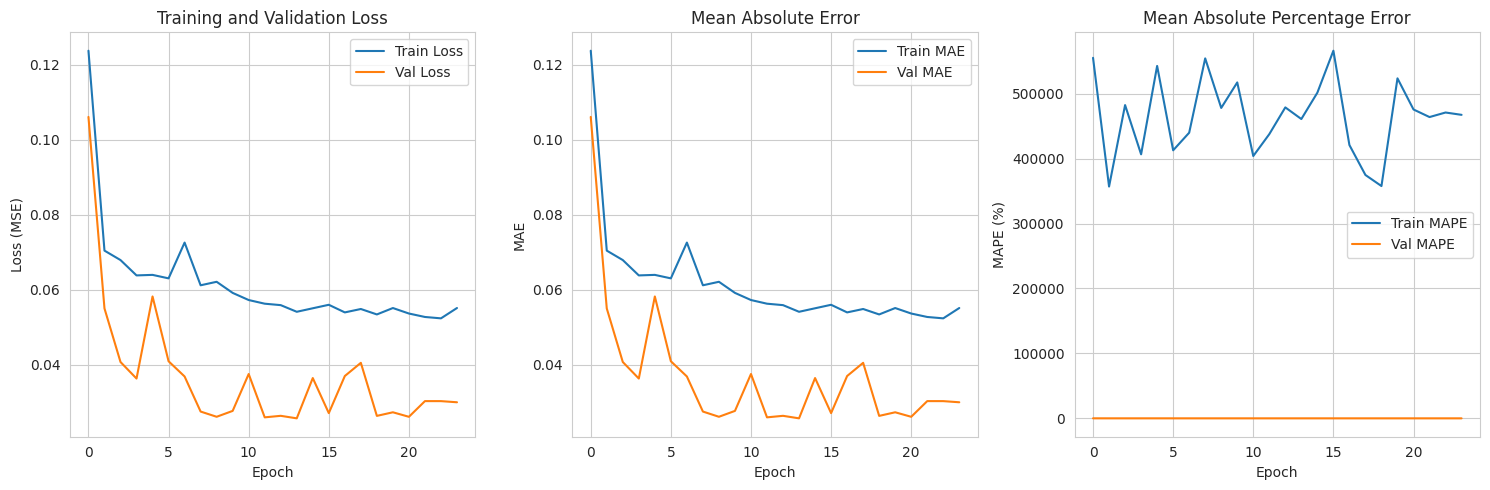


Training complete. Files saved:
  keras_model: models/lstm_model.keras
  history: models/training_history.json
  plot: models/training_curves.png

Training Complete!


In [ ]:
config = LSTMConfig(
    sequence_length=sequence_length,
    n_features=len(feature_cols),
    lstm_units_1=512,
    lstm_units_2=256,
    dropout_rate=0.2,
    dense_units=128,
    output_dim=1,  # Single output: percentage change prediction
    learning_rate=0.001,
    batch_size=32,
    epochs=50,
    validation_split=0.0
)

print("Building and training LSTM model...")
print("=" * 60)
print("Loss function: MAE (Mean Absolute Error)")
print("Optimizer: Adam")
print("=" * 60)

import os
os.makedirs('models', exist_ok=True)

model, history, file_paths = create_and_train_lstm(
    X_train, y_train,
    X_val, y_val,
    config=config,
    model_dir='models',
    verbose=1
)

print("\n" + "=" * 60)
print("Training Complete!")
print("=" * 60)

---

## Cell 13: Convert Model to ONNX

In [ ]:
print("Converting Keras model to ONNX format...\n")

onnx_model_path = 'models/stock_forecast_lstm.onnx'

onnx_path = convert_to_onnx(
    model_path='models/lstm_model.keras',
    onnx_path=onnx_model_path,
)

print(f"Model converted successfully!")
print(f"ONNX model saved to: {onnx_path}")

import os
keras_size = os.path.getsize('models/lstm_model.keras') / 1024
onnx_size = os.path.getsize(onnx_path) / 1024

print(f"\nModel Size Comparison:")
print(f"  Keras (.keras):  {keras_size:.2f} KB")
print(f"  ONNX (.onnx): {onnx_size:.2f} KB")
print(f"  Compression:  {keras_size/onnx_size:.2f}x")

Converting Keras model to ONNX format...



I0000 00:00:1765303776.346603  197808 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1765303776.346883  197808 single_machine.cc:361] Starting new session
I0000 00:00:1765303776.347794  197808 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1765303776.641909  197808 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1765303776.722112  197808 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1765303776.722339  197808 single_machine.cc:361] Starting new session
I0000 00:00:1765303776.722888  197808 gpu_device.cc:2022] Created device /job:localhost/replic

Saved artifact at 'models/stock_forecast_lstm.onnx'.
Model converted successfully!
ONNX model saved to: models/stock_forecast_lstm.onnx

Model Size Comparison:
  Keras (.keras):  22282.08 KB
  ONNX (.onnx): 7429.56 KB
  Compression:  3.00x


---

## Cell 14: Verify ONNX Model

In [ ]:
verification = verify_onnx(onnx_model_path)

print("=" * 60)
print("ONNX Model Verification")
print("=" * 60)
print(f"Valid:              {verification['is_valid']}")
print(f"Error:              {verification['error']}")
print(f"Opset Version:      {verification['opset_version']}")
print(f"Number of Nodes:    {verification['num_nodes']}")
print("=" * 60)

if verification['is_valid']:
    print("\nONNX model is valid and ready for deployment!")
else:
    print(f"\nVerification failed: {verification['error']}")
    raise Exception

ONNX Model Verification
Valid:              True
Error:              None
Opset Version:      15
Number of Nodes:    28

ONNX model is valid and ready for deployment!


---

## Cell 15: Compare TensorFlow vs ONNX Inference

In [ ]:
print("Comparing TensorFlow vs ONNX Runtime performance...\n")

comparison = compare_frameworks_inference(
    keras_model_path='models/lstm_model.keras',
    onnx_model_path=onnx_model_path,
    test_input=X_test[:100]
)

print("=" * 70)
print("Framework Comparison Results")
print("=" * 70)
print(f"TensorFlow inference time:  {comparison['tensorflow_time']:.6f} seconds")
print(f"ONNX Runtime inference time: {comparison['onnx_time']:.6f} seconds")
print(f"Speedup:                     {comparison['speedup']:.2f}x")
print("-" * 70)
print(f"Max numerical difference:    {comparison['max_difference']:.2e}")
print(f"Mean numerical difference:   {comparison['mean_difference']:.2e}")
print(f"Numerically equivalent:      {comparison['numerically_close']}")
print("=" * 70)

if comparison['speedup'] > 1:
    print(f"\nONNX Runtime is {comparison['speedup']:.2f}x faster!")
else:
    print(f"\nTensorFlow is {1/comparison['speedup']:.2f}x faster")

if comparison['numerically_close']:
    print("Models produce numerically equivalent results")

Comparing TensorFlow vs ONNX Runtime performance...

Framework Comparison Results
TensorFlow inference time:  0.621929 seconds
ONNX Runtime inference time: 0.048514 seconds
Speedup:                     12.82x
----------------------------------------------------------------------
Max numerical difference:    4.20e-06
Mean numerical difference:   1.70e-06
Numerically equivalent:      True

ONNX Runtime is 12.82x faster!
Models produce numerically equivalent results


---

## Cell 16: Run Inference with ONNX Runtime

In [ ]:
print("Running inference with ONNX Runtime...\n")

onnx_session = ONNXInferenceSession(onnx_model_path)

print(f"Input shape: {onnx_session.get_input_shape()}")
print(f"Output shape: {onnx_session.get_output_shape()}")

# Get predictions (scaled percentage changes)
onnx_predictions_scaled = onnx_session.predict(X_test)

# Denormalize percentage change predictions
# We need to create a dummy array with all features to use the scaler
target_col_idx = all_cols.index(target_col)
dummy_array = np.zeros((len(onnx_predictions_scaled), len(all_cols)))
dummy_array[:, target_col_idx] = onnx_predictions_scaled.flatten()
onnx_predictions_pct = scaler.inverse_transform(dummy_array)[:, target_col_idx]

# Denormalize actual percentage changes
dummy_array_actual = np.zeros((len(y_test), len(all_cols)))
dummy_array_actual[:, target_col_idx] = y_test.flatten()
y_test_pct = scaler.inverse_transform(dummy_array_actual)[:, target_col_idx]

# Convert percentage changes to actual prices for visualization
# We need the previous close price for each prediction
test_close_prices = test_df['Close'].values[sequence_length-1:sequence_length-1+len(y_test_pct)]

# Predicted price = Previous close * (1 + predicted percentage change)
onnx_predictions_unscaled = test_close_prices * (1 + onnx_predictions_pct)

# Actual price = Previous close * (1 + actual percentage change)
y_test_unscaled = test_close_prices * (1 + y_test_pct)

print(f"\nInference complete!")
print(f"Number of predictions: {len(onnx_predictions_scaled)}")
print(f"\nSample predictions (percentage change):")
for i in range(min(5, len(onnx_predictions_pct))):
    print(f"  Predicted: {onnx_predictions_pct[i]:+.4f} ({onnx_predictions_pct[i]*100:+.2f}%), " +
          f"Actual: {y_test_pct[i]:+.4f} ({y_test_pct[i]*100:+.2f}%)")

Running inference with ONNX Runtime...

Input shape: ['unk__130', 60, 13]
Output shape: ['unk__131', 1]

Inference complete!
Number of predictions: 71

Sample predictions (percentage change):
  Predicted: +0.0044 (+0.44%), Actual: -0.0072 (-0.72%)
  Predicted: +0.0044 (+0.44%), Actual: +0.0047 (+0.47%)
  Predicted: +0.0044 (+0.44%), Actual: +0.0015 (+0.15%)
  Predicted: +0.0044 (+0.44%), Actual: -0.0028 (-0.28%)
  Predicted: +0.0043 (+0.43%), Actual: -0.0042 (-0.42%)


---

## Cell 17: Evaluate Forecast Performance

In [ ]:
# Evaluate on percentage change predictions (primary metric)
pct_mae = np.mean(np.abs(y_test_pct - onnx_predictions_pct))
pct_rmse = np.sqrt(np.mean((y_test_pct - onnx_predictions_pct) ** 2))
pct_r2 = 1 - (np.sum((y_test_pct - onnx_predictions_pct) ** 2) / np.sum((y_test_pct - y_test_pct.mean()) ** 2))

# Directional accuracy (did we predict the right direction?)
correct_direction = np.sum((y_test_pct > 0) == (onnx_predictions_pct > 0))
directional_accuracy_pct = (correct_direction / len(y_test_pct)) * 100

print("=" * 70)
print("Percentage Change Prediction Performance (Primary Metric)")
print("=" * 70)
print(f"Mean Absolute Error (MAE):       {pct_mae:.6f} ({pct_mae*100:.4f}%)")
print(f"Root Mean Squared Error (RMSE):  {pct_rmse:.6f} ({pct_rmse*100:.4f}%)")
print(f"R² Score:                        {pct_r2:.4f}")
print(f"Directional Accuracy:            {directional_accuracy_pct:.2f}%")
print("=" * 70)

# Also evaluate on reconstructed prices (secondary metric for comparison)
metrics = evaluate_forecasts(y_test_unscaled, onnx_predictions_unscaled)

print("\n" + "=" * 70)
print("Reconstructed Price Forecasting Performance (Secondary Metric)")
print("=" * 70)
print(f"Mean Absolute Error (MAE):       ${metrics['MAE']:.4f}")
print(f"Root Mean Squared Error (RMSE):  ${metrics['RMSE']:.4f}")
print(f"Mean Absolute % Error (MAPE):    {metrics['MAPE']:.2f}%")
print(f"R² Score:                        {metrics['R2']:.4f}")
print(f"Directional Accuracy:            {metrics['Directional_Accuracy']:.2f}%")
print("=" * 70)

avg_price = y_test_unscaled.mean()
print(f"\nAverage stock price: ${avg_price:.2f}")
print(f"MAE as % of avg price: {(metrics['MAE'] / avg_price) * 100:.2f}%")

if directional_accuracy_pct > 55:
    print(f"\nGood directional accuracy: {directional_accuracy_pct:.1f}% > 55%")
else:
    print(f"\nNote: Directional accuracy {directional_accuracy_pct:.1f}% (random = 50%)")

Percentage Change Prediction Performance (Primary Metric)
Mean Absolute Error (MAE):       0.007362 (0.7362%)
Root Mean Squared Error (RMSE):  0.010160 (1.0160%)
R² Score:                        -0.0763
Directional Accuracy:            53.52%

Reconstructed Price Forecasting Performance (Secondary Metric)
Mean Absolute Error (MAE):       $7.0093
Root Mean Squared Error (RMSE):  $9.7002
Mean Absolute % Error (MAPE):    0.73%
R² Score:                        0.9382
Directional Accuracy:            48.57%

Average stock price: $955.33
MAE as % of avg price: 0.73%

Note: Directional accuracy 53.5% (random = 50%)


---

## Cell 18: Visualize Predictions vs Actual

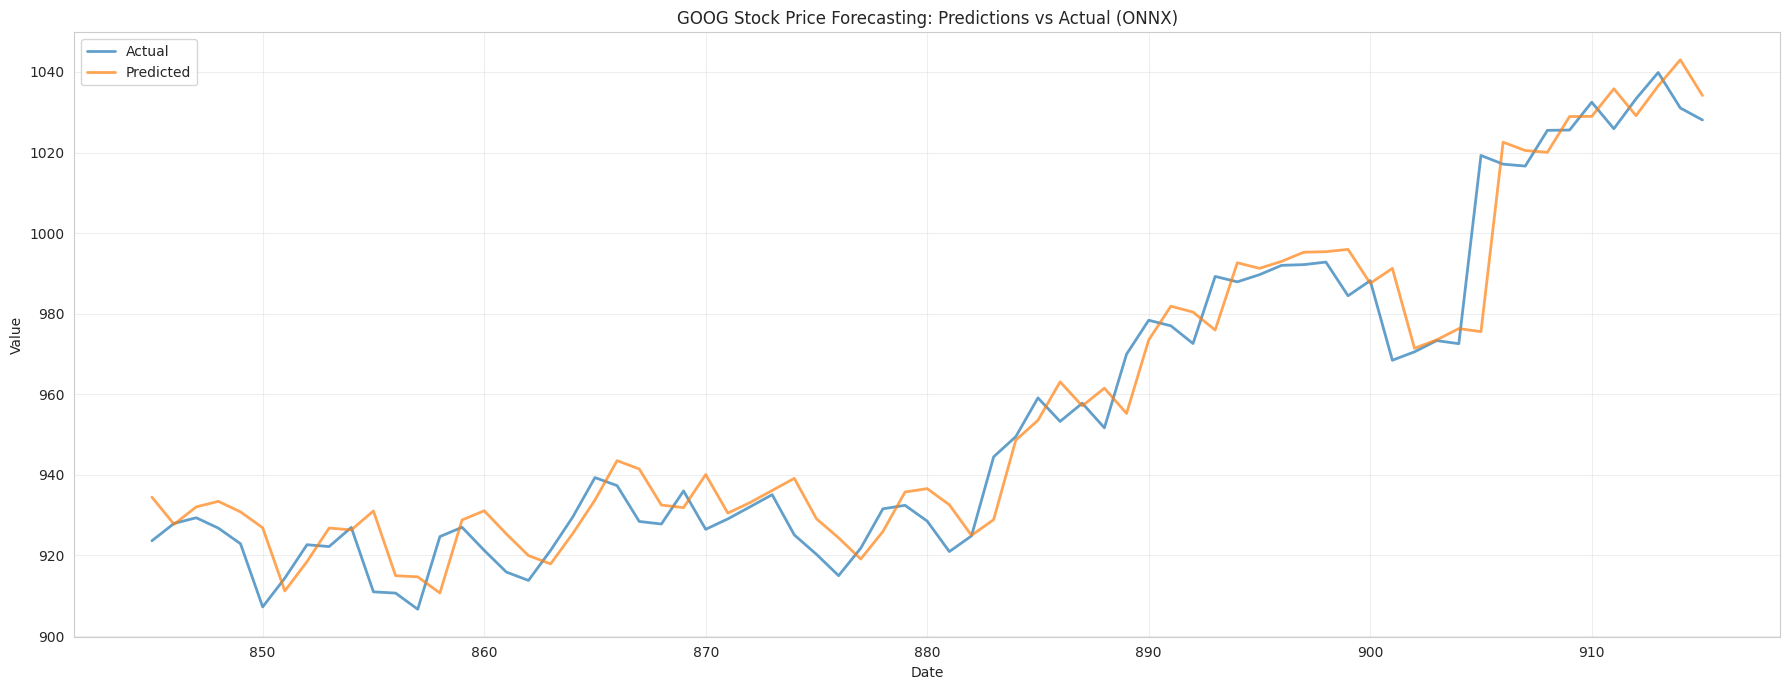

In [ ]:
test_dates = test_df.index[sequence_length:sequence_length + len(y_test_unscaled)]

plot_predictions_vs_actual(
    y_true=y_test_unscaled,
    y_pred=onnx_predictions_unscaled,
    dates=test_dates,
    title='GOOG Stock Price Forecasting: Predictions vs Actual (ONNX)',
    figsize=(18, 7)
)

recent_window = 252
if len(y_test_unscaled) > recent_window:
    plot_predictions_vs_actual(
        y_true=y_test_unscaled[-recent_window:],
        y_pred=onnx_predictions_unscaled[-recent_window:],
        dates=test_dates[-recent_window:],
        title='GOOG Stock Price Forecasting: Last Year (ONNX)',
        figsize=(18, 7)
    )

---

## Cell 20: Sample Predictions Table

In [ ]:
sample_size = 20
sample_indices = np.linspace(0, len(y_test_unscaled) - 1, sample_size, dtype=int)

results_df = pd.DataFrame({
    'Date': test_dates[sample_indices],
    'Actual % Chg': y_test_pct[sample_indices] * 100,
    'Pred % Chg': onnx_predictions_pct[sample_indices] * 100,
    'Actual Price': y_test_unscaled[sample_indices],
    'Pred Price': onnx_predictions_unscaled[sample_indices],
    'Price Error': y_test_unscaled[sample_indices] - onnx_predictions_unscaled[sample_indices]
})

# Format for display
results_df['Actual % Chg'] = results_df['Actual % Chg'].apply(lambda x: f"{x:+.2f}%")
results_df['Pred % Chg'] = results_df['Pred % Chg'].apply(lambda x: f"{x:+.2f}%")
results_df['Actual Price'] = results_df['Actual Price'].apply(lambda x: f"${x:.2f}")
results_df['Pred Price'] = results_df['Pred Price'].apply(lambda x: f"${x:.2f}")
results_df['Price Error'] = results_df['Price Error'].apply(lambda x: f"${x:.2f}")

print("Sample Predictions (Percentage Change & Reconstructed Prices):")
print(results_df.to_string(index=False))

Sample Predictions (Percentage Change & Reconstructed Prices):
 Date Actual % Chg Pred % Chg Actual Price Pred Price Price Error
  845       -0.72%     +0.44%      $923.65    $934.48     $-10.83
  848       -0.28%     +0.44%      $926.79    $933.44      $-6.65
  852       +0.91%     +0.45%      $922.67    $918.48       $4.19
  856       -0.03%     +0.44%      $910.67    $914.99      $-4.32
  859       +0.25%     +0.45%      $927.00    $928.81      $-1.81
  863       +0.82%     +0.45%      $921.29    $917.91       $3.38
  867       -0.95%     +0.44%      $928.45    $941.47     $-13.02
  870       -1.02%     +0.43%      $926.50    $940.09     $-13.59
  874       -1.07%     +0.43%      $925.11    $939.14     $-14.03
  878       +1.06%     +0.45%      $931.58    $925.95       $5.63
  881       -0.81%     +0.44%      $920.97    $932.59     $-11.62
  885       +1.01%     +0.43%      $959.11    $953.55       $5.56
  889       +1.92%     +0.37%      $969.96    $955.25      $14.71
  892       -

---

## Cell 21: Feature Importance Analysis

Analyzing which features most impact percentage change predictions...

Feature Importance for Percentage Change Prediction:
------------------------------------------------------------
 1. MACD_Signal         : 0.004409
 2. MACD                : 0.003127
 3. RSI                 : 0.002359
 4. Volume_Ratio        : 0.000777
 5. EMA_20              : 0.000742
 6. BB_Width            : 0.000731
 7. SMA_20              : 0.000554
 8. ATR                 : 0.000346
 9. Open                : 0.000315
10. Low                 : 0.000244
11. Close               : 0.000222
12. Volume              : 0.000105
13. High                : 0.000094


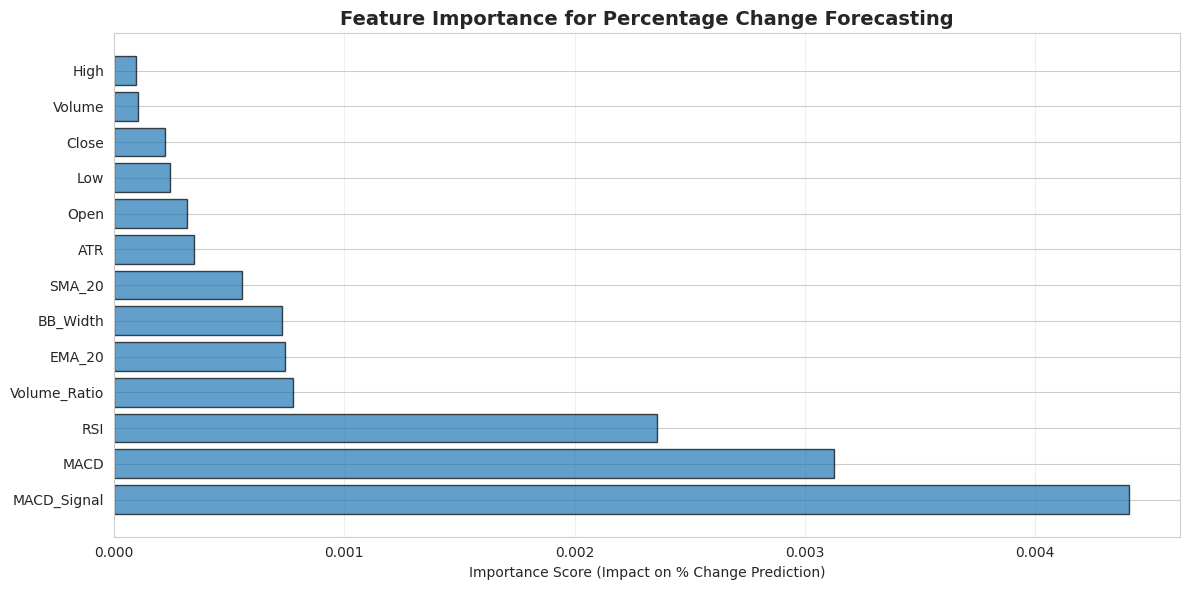

In [ ]:
print("Analyzing which features most impact percentage change predictions...\n")

feature_importance = []
baseline_pred = onnx_session.predict(X_test[:100])

for i, feature in enumerate(feature_cols):
    X_test_perturbed = X_test[:100].copy()
    X_test_perturbed[:, :, i] = np.random.permutation(X_test_perturbed[:, :, i])
    perturbed_pred = onnx_session.predict(X_test_perturbed)

    importance = np.mean(np.abs(baseline_pred - perturbed_pred))
    feature_importance.append((feature, importance))

feature_importance.sort(key=lambda x: x[1], reverse=True)

print("Feature Importance for Percentage Change Prediction:")
print("-" * 60)
for rank, (feature, importance) in enumerate(feature_importance, 1):
    print(f"{rank:2d}. {feature:20s}: {importance:.6f}")

fig, ax = plt.subplots(figsize=(12, 6))
features, importances = zip(*feature_importance)
ax.barh(features, importances, alpha=0.7, edgecolor='black')
ax.set_xlabel('Importance Score (Impact on % Change Prediction)')
ax.set_title('Feature Importance for Percentage Change Forecasting', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---

## Cell 22: Forecast Report

In [ ]:
report_df = create_forecast_report(
    y_true=y_test_unscaled,
    y_pred=onnx_predictions_unscaled,
    model_name='LSTM + ONNX'
)

print("\n" + "=" * 60)
print("Forecast Performance Report")
print("=" * 60)
print(report_df.to_string(index=False))
print("=" * 60)


Forecast Performance Report
      Model    MAE   RMSE  MAPE     R² Direction Acc
LSTM + ONNX 7.0093 9.7002 0.73% 0.9382        48.57%
